# Naive Bayes Classifier (ECOLI)

Ini adalah tahap modeling klasifikasi data ecoli menggunakan metode Naive Bayes dengan kondisi

Data ecoli yang belum di lakukan oversampling

Data ecoli yang sudah di lakukan oversampling menggunakan SMOTE

Data ecoli yang sudah di lakukan oversampling menggunakan ADASYN

kemudian di bandingkan apakah ada penambahan akurasi saat setelah data di lakukan oversampling

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
engine = create_engine("mysql+pymysql://root:@localhost:3306/ecoli")

# ambil data dari tabel
df = pd.read_sql("SELECT * FROM ecoli;", engine)
class_counts = df['class_label'].value_counts().sort_index()
nt = df.drop(columns=["class_label", "id_protein"])
ns = df["class_label"]
print("\nInfo Dataset:")
df


Info Dataset:


,id_protein,feature1,feature2,feature3,feature4,feature5,feature6,feature7,class_label
0,AAS_ECOLI,0.44,0.52,0.48,0.5,0.43,0.47,0.54,im
1,AAT_ECOLI,0.49,0.29,0.48,0.5,0.56,0.24,0.35,cp
2,ACEA_ECOLI,0.07,0.40,0.48,0.5,0.54,0.35,0.44,cp
3,ACEK_ECOLI,0.56,0.40,0.48,0.5,0.49,0.37,0.46,cp
4,ACKA_ECOLI,0.59,0.49,0.48,0.5,0.52,0.45,0.36,cp
...,...,...,...,...,...,...,...,...,...
332,XYLA_ECOLI,0.16,0.43,0.48,0.5,0.54,0.27,0.37,cp
333,XYLE_ECOLI,0.69,0.39,0.48,0.5,0.57,0.76,0.79,im
334,XYLF_ECOLI,0.59,0.61,0.48,0.5,0.42,0.42,0.37,pp
335,YCEE_ECOLI,0.52,0.54,0.48,0.5,0.62,0.76,0.79,im


accuracy_score : 0.7647058823529411
Classification Report:
               precision    recall  f1-score   support

          cp       0.96      0.96      0.96        25
          im       0.77      0.81      0.79        21
         imL       0.00      0.00      0.00         0
         imS       0.00      0.00      0.00         0
         imU       0.00      0.00      0.00         5
          om       0.00      0.00      0.00         5
         omL       0.00      0.00      0.00         1
          pp       0.61      1.00      0.76        11

    accuracy                           0.76        68
   macro avg       0.29      0.35      0.31        68
weighted avg       0.69      0.76      0.72        68



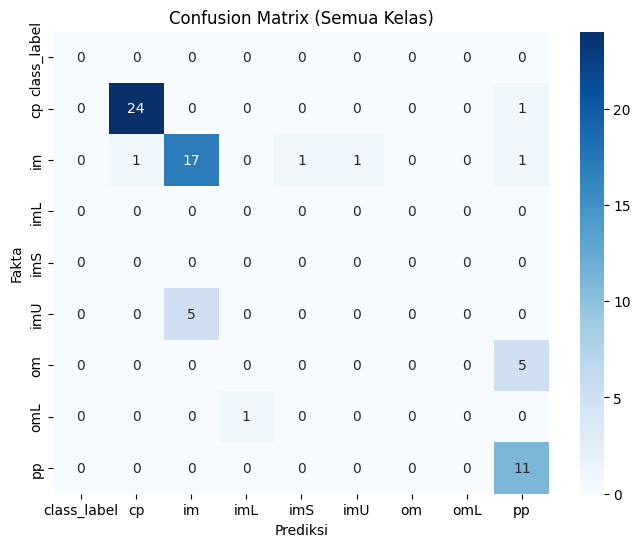

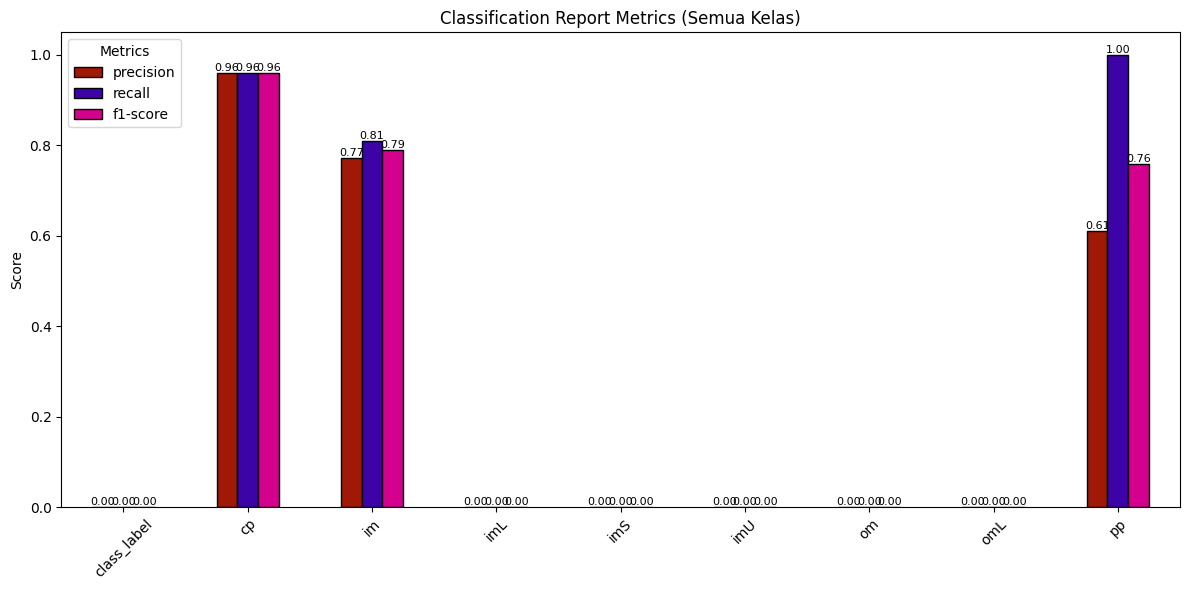

In [3]:
from sqlalchemy import create_engine, text
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Koneksi ke MySQL
engine = create_engine("mysql+pymysql://root:@localhost:3306/ecoli")

query = """
SELECT feature1, feature2, feature3, feature4, feature5, feature6, feature7, class_label
FROM ecoli
"""

df = pd.read_sql(query, engine)

# Pisahkan fitur dan target
X = df.drop(columns=["class_label"])
y = df["class_label"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

# Prediksi
prediksi = nb.predict(X_test)

# Evaluasi
print(f"accuracy_score : {accuracy_score(y_test, prediksi)}")
print("Classification Report:\n", classification_report(y_test, prediksi, zero_division=0))

# Confusion Matrix
labels = np.unique(np.concatenate([y_train, y_test]))
cm = confusion_matrix(y_test, prediksi, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Prediksi")
plt.ylabel("Fakta")
plt.title("Confusion Matrix (Semua Kelas)")
plt.show()

# Classification report ke DataFrame
all_labels = np.unique(np.concatenate([y_train, y_test]))
report = classification_report(
    y_test, prediksi, labels=all_labels,
    output_dict=True, zero_division=0
)
df_report = pd.DataFrame(report).transpose()

metrics_df = df_report[['precision','recall','f1-score']].iloc[:-3]

# Plot Metrics
ax = metrics_df.plot(
    kind='bar',
    figsize=(12,6),
    color=["#a01806", "#3c03a7", "#d4008e"],
    edgecolor='black'
)
plt.title("Classification Report Metrics (Semua Kelas)")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.xticks(rotation=45)

for p in ax.patches:
    value = f"{p.get_height():.2f}"
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(value, (x, y), ha='center', va='bottom', fontsize=8, rotation=0)

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()


# Modeling Klasifikasi menggunakan Naive bayes pada data Ecoli setelah di Oversampling menggunakan SMOT

In [4]:


# Load dataset hasil oversampling SMOTE
data_smote = pd.read_csv("../balance/ecoli_balanced_smote.csv")  

# Pastikan nama kolom target sesuai
x_smote = data_smote.drop(columns=["class_label"])
y_smote = data_smote["class_label"]

# Split data
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    x_smote, y_smote, test_size=0.2, random_state=42
)

# Encode kolom kategori ke numerik
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_smote = encoder.fit_transform(X_train_smote)
X_test_smote = encoder.transform(X_test_smote)

# Scaling fitur
scaler = StandardScaler()
X_train_smote = scaler.fit_transform(X_train_smote)
X_test_smote = scaler.transform(X_test_smote)

# Train Gaussian Naive Bayes
nb = GaussianNB()
nb.fit(X_train_smote, y_train_smote)

# Prediksi
prediksi_smote = nb.predict(X_test_smote)

print(f"accuracy_score : {accuracy_score(y_test_smote, prediksi_smote):.4f}")
print("Classification Report:\n", classification_report(y_test_smote, prediksi_smote, zero_division=0))

# Confusion Matrix
labels = np.unique(np.concatenate([y_train_smote, y_test_smote]))
cm = confusion_matrix(y_test_smote, prediksi_smote, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Prediksi")
plt.ylabel("Fakta")
plt.title("Confusion Matrix (Semua Kelas)")
plt.show()

# Classification report ke DataFrame
report = classification_report(
    y_test_smote, prediksi_smote, labels=labels,
    output_dict=True, zero_division=0
)
df_report = pd.DataFrame(report).transpose()

metrics_df = df_report[['precision','recall','f1-score']].iloc[:-3]

# Plot Metrics
ax = metrics_df.plot(
    kind='bar', 
    figsize=(12,6), 
    color=["#a01806", "#3c03a7", "#d4008e"], 
    edgecolor='black'
)
plt.title("Classification Report Metrics (Semua kelas)")
plt.ylabel("Score")
plt.ylim(0,1.05) 
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()


NameError: name 'OrdinalEncoder' is not defined

# Modeling Klasifikasi menggunakan Naive bayes pada data ecoli setelah di oversampling menggunakan ADASYN

accuracy_score : 0.8095238095238095
akurasi lengkap:
               precision    recall  f1-score   support

          cp       0.85      0.97      0.90        29
          im       0.90      0.58      0.71        31
         imL       1.00      1.00      1.00        31
         imS       0.97      1.00      0.98        32
         imU       0.93      0.74      0.83        35
          om       1.00      0.33      0.50        30
         omL       1.00      1.00      1.00        24
          pp       0.35      0.95      0.51        19

    accuracy                           0.81       231
   macro avg       0.87      0.82      0.80       231
weighted avg       0.90      0.81      0.81       231



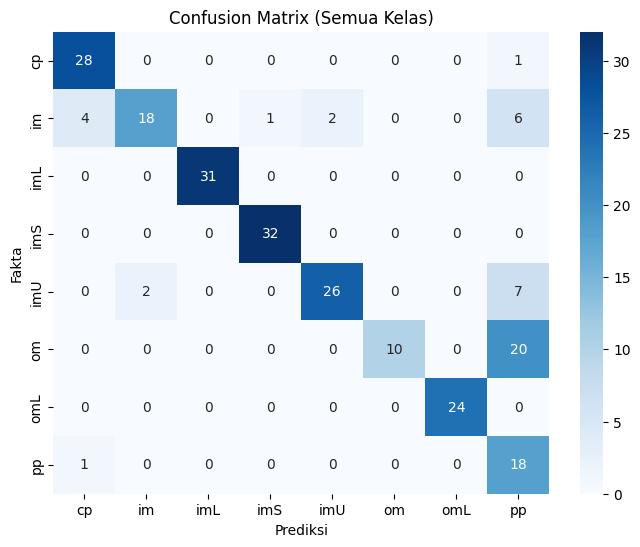

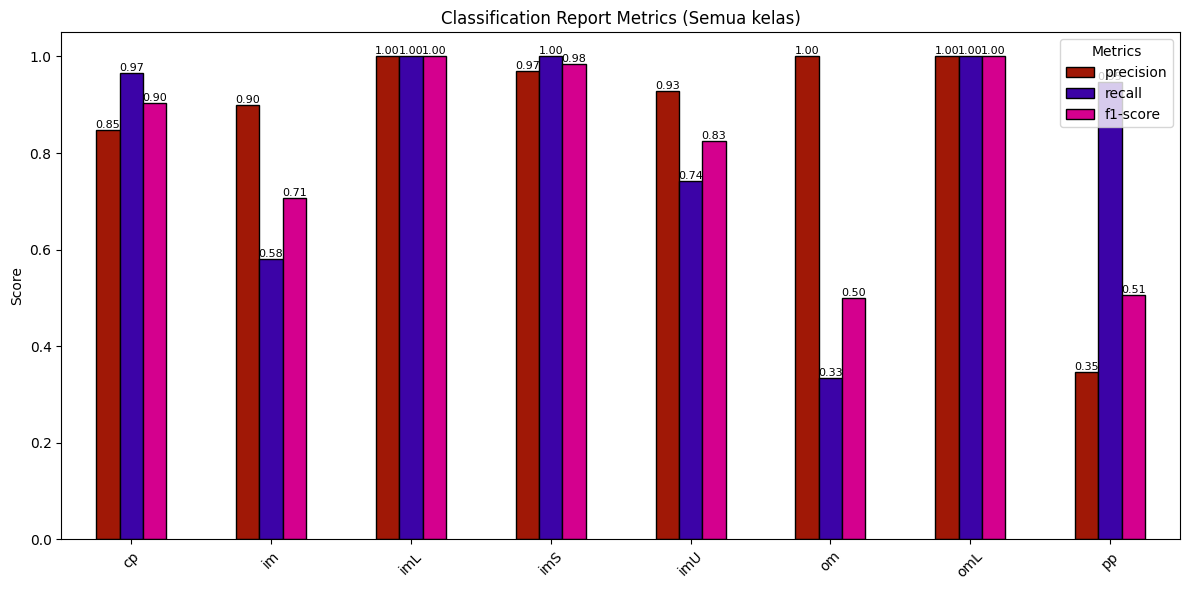

In [ ]:
data_adasyn = pd.read_csv("../balance/hasil_oversampling_ADASYN.csv")
x_adasyn = data_adasyn.drop(columns=["class_label"])
y_adasyn = data_adasyn["class_label"]

X_train_adasyn, X_test_adasyn, y_train_adasyn, y_test_adasyn = train_test_split(
    x_adasyn, y_adasyn, test_size=0.2, random_state=42
)

nb = GaussianNB()

nb.fit(X_train_adasyn, y_train_adasyn)

prediksi_adasyn = nb.predict(X_test_adasyn)

print(f"accuracy_score : {accuracy_score(y_test_adasyn, prediksi_adasyn)}")
print("akurasi lengkap:\n", classification_report(y_test_adasyn, prediksi_adasyn))

# confuison matrix

labels = np.unique(np.concatenate([y_train_adasyn, y_test_adasyn]))

cm = confusion_matrix(y_test_adasyn, prediksi_adasyn, labels=labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Prediksi")
plt.ylabel("Fakta")
plt.title("Confusion Matrix (Semua Kelas)")
plt.show()

all_labels = np.unique(np.concatenate([y_train_adasyn, y_test_adasyn]))

report = classification_report(
    y_test_adasyn, prediksi_adasyn, labels=all_labels,
    output_dict=True, zero_division=0
)

df_report = pd.DataFrame(report).transpose()

metrics_df = df_report[['precision','recall','f1-score']].iloc[:-3]

# warna diagram batang
ax = metrics_df.plot(
    kind='bar', 
    figsize=(12,6), 
    color=["#a01806", "#3c03a7", "#d4008e"], # biru, oranye, hijau
    edgecolor='black'
)

plt.title("Classification Report Metrics (Semua kelas)")
plt.ylabel("Score")
plt.ylim(0,1.05) 
plt.xticks(rotation=45)

# diagram batang
for p in ax.patches:
    value = f"{p.get_height():.2f}"
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(value, (x, y), ha='center', va='bottom', fontsize=8, rotation=0)

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

# Perbandingan akurasi antara data sebelum di oversampling dan sesudah

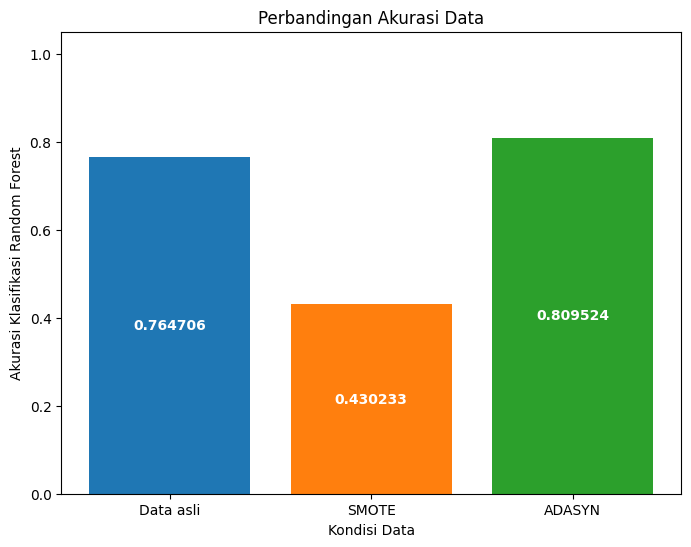

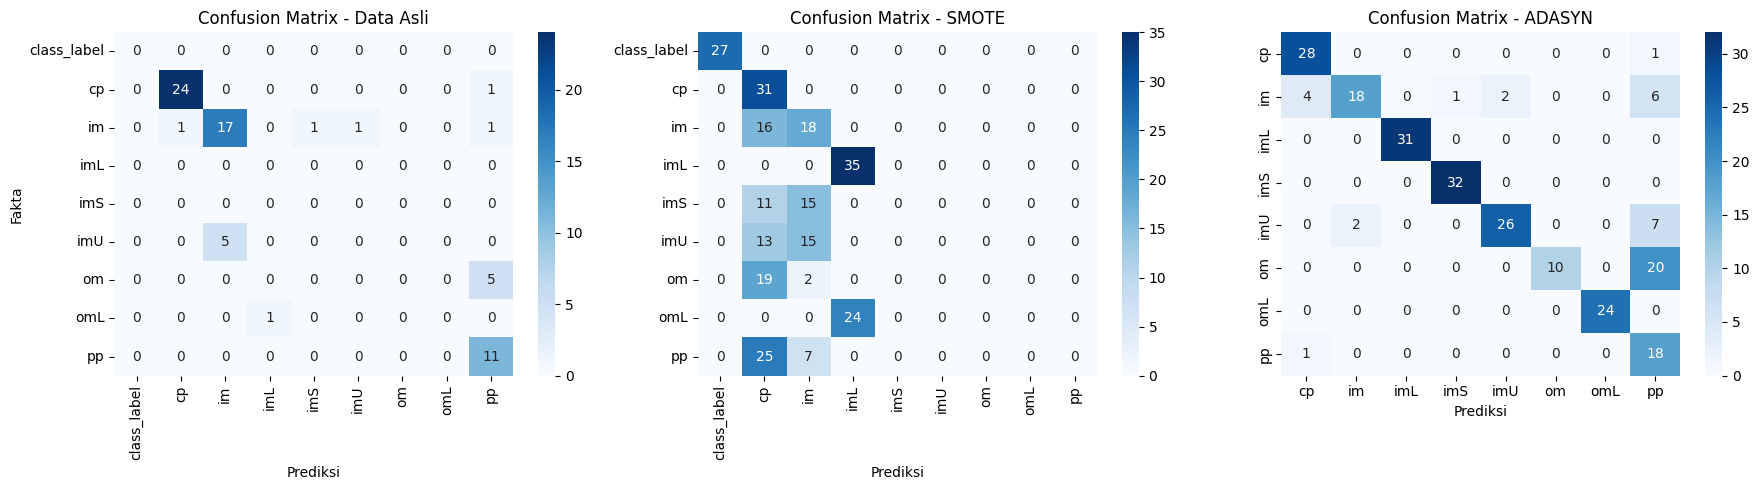

In [ ]:
# data yang sebelum di overesampling 

akurasi = accuracy_score(y_test, prediksi)

# data yang sudah di oversampling menggunakan SMOTE

akurasi_smote = accuracy_score(y_test_smote, prediksi_smote)

# data yang sudah di oversampling menggunakan ADASYN

akurasi_adasyn = accuracy_score(y_test_adasyn, prediksi_adasyn)


label = ['Data asli', 'SMOTE', 'ADASYN']
temp = [akurasi, akurasi_smote, akurasi_adasyn]

fig, ax = plt.subplots(figsize=(8,6))

bc = ax.bar(label, temp, color=['#1f77b4','#ff7f0e','#2ca02c'])

ax.bar_label(bc, label_type='center', color='w', fontweight='bold')

ax.set(
    xlabel='Kondisi Data',
    ylabel='Akurasi Klasifikasi Random Forest',
    title='Perbandingan Akurasi Data'
)

ax.set_ylim(0, 1.05)

plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Data asli
labels = np.unique(np.concatenate([y_train, y_test]))
cm = confusion_matrix(y_test, prediksi, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("Confusion Matrix - Data Asli")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Fakta")

# Data SMOTE
labels = np.unique(np.concatenate([y_train_smote, y_test_smote]))
cm = confusion_matrix(y_test_smote, prediksi_smote, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("Confusion Matrix - SMOTE")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("")

# Data ADASYN
labels = np.unique(np.concatenate([y_train_adasyn, y_test_adasyn]))
cm = confusion_matrix(y_test_adasyn, prediksi_adasyn, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[2])
axes[2].set_title("Confusion Matrix - ADASYN")
axes[2].set_xlabel("Prediksi")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()